In [31]:
%%writefile gas_prediction_fixed.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import joblib
import datetime
import warnings
import os
warnings.filterwarnings("ignore")

# Try to import XGBoost, fall back to RandomForest if not available
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available, using RandomForest as default")
    XGBOOST_AVAILABLE = False

class GasUsagePredictionModel:
    def __init__(self, data_path='data.csv'):
        """Initialize the gas usage prediction model."""
        self.data_path = data_path
        self.model = None
        self.scaler = StandardScaler()
        self.features = None

    def load_data(self):
        """Load and preprocess the data."""
        # Load the CSV data
        df = pd.read_csv(self.data_path)

        # Convert timestamp to datetime
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')

        # Create time-based features
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['day_of_month'] = df['timestamp'].dt.day
        df['month'] = df['timestamp'].dt.month
        df['year'] = df['timestamp'].dt.year

        # Convert hour to cyclical features to represent time's cyclic nature
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

        # Add day of week as cyclical features
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

        # Sort by timestamp to maintain time order
        df = df.sort_values('timestamp')

        # Calculate lag features (previous hour, day, week)
        df['hourly_volume_lag1'] = df['hourly_volume'].shift(1)
        df['hourly_volume_lag24'] = df['hourly_volume'].shift(24)  # Previous day, same hour
        df['hourly_volume_lag168'] = df['hourly_volume'].shift(168)  # Previous week, same hour

        # Calculate rolling averages
        df['hourly_volume_rolling_mean_24h'] = df['hourly_volume'].rolling(window=24).mean()
        df['hourly_volume_rolling_mean_7d'] = df['hourly_volume'].rolling(window=168).mean()

        # Drop rows with NaN values from lag creation
        df = df.dropna()

        # Store a copy of the original data
        self.data = df.copy()

        return df

    def prepare_features(self, df=None):
        """Prepare features for model training."""
        if df is None:
            df = self.load_data()

        # Features selection
        self.features = [
            'density', 'pressure_diff', 'pressure', 'temperature',
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'day_of_month', 'month',
            'hourly_volume_lag1', 'hourly_volume_lag24', 'hourly_volume_lag168',
            'hourly_volume_rolling_mean_24h', 'hourly_volume_rolling_mean_7d'
        ]

        # Target variable
        target = 'hourly_volume'

        # Split features and target
        X = df[self.features]
        y = df[target]

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        return X_scaled, y, X.columns

    def train_model(self, model_type='random_forest'):
        """Train the prediction model."""
        # If XGBoost requested but not available, fall back to RandomForest
        if model_type == 'xgboost' and not XGBOOST_AVAILABLE:
            print("XGBoost not available, using Random Forest instead")
            model_type = 'random_forest'

        # Load and prepare data
        df = self.load_data()
        X_scaled, y, feature_names = self.prepare_features(df)

        # Split data into train and test sets (80-20 split)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, shuffle=False  # Keep time order
        )

        # Select model type
        if model_type == 'linear':
            self.model = LinearRegression()
            print("Using Linear Regression")
        elif model_type == 'random_forest':
            self.model = RandomForestRegressor(
                n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
            )
            print("Using Random Forest Regressor")
        elif model_type == 'gradient_boosting':
            self.model = GradientBoostingRegressor(
                n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
            )
            print("Using Gradient Boosting Regressor")
        elif model_type == 'xgboost' and XGBOOST_AVAILABLE:
            self.model = XGBRegressor(
                n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
            )
            print("Using XGBoost Regressor")
        else:
            raise ValueError(f"Unknown model type: {model_type}")

        # Train the model
        print("Training the model...")
        self.model.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = self.model.predict(X_test)

        # Evaluate the model
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"\nModel Evaluation:")
        print(f"Model Type: {model_type}")
        print(f"Root Mean Squared Error: {rmse:.4f}")
        print(f"Mean Absolute Error: {mae:.4f}")
        print(f"R² Score: {r2:.4f}")

        # Plot actual vs predicted
        plt.figure(figsize=(15, 6))
        plt.plot(df['timestamp'].iloc[-len(y_test):], y_test.values, label='Actual', linewidth=2)
        plt.plot(df['timestamp'].iloc[-len(y_test):], y_pred, label='Predicted', linewidth=2, alpha=0.8)
        plt.title('Actual vs Predicted Hourly Gas Usage')
        plt.xlabel('Date')
        plt.ylabel('Hourly Volume (min m³)')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Feature importance for tree-based models
        if model_type in ['random_forest', 'gradient_boosting'] or (model_type == 'xgboost' and XGBOOST_AVAILABLE):
            feature_importance = pd.DataFrame({
                'Feature': feature_names,
                'Importance': self.model.feature_importances_
            }).sort_values('Importance', ascending=False)

            plt.figure(figsize=(12, 8))
            top_features = feature_importance.head(10)
            plt.barh(range(len(top_features)), top_features['Importance'])
            plt.yticks(range(len(top_features)), top_features['Feature'])
            plt.title(f'Top 10 Feature Importances - {model_type}')
            plt.xlabel('Importance')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()

            print("\nTop 5 Most Important Features:")
            for i, (idx, row) in enumerate(feature_importance.head().iterrows()):
                print(f"{i+1}. {row['Feature']}: {row['Importance']:.4f}")

        return {
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'model': self.model
        }

    def evaluate_all_models(self):
        """Train and compare different model types."""
        models = ['linear', 'random_forest', 'gradient_boosting']
        if XGBOOST_AVAILABLE:
            models.append('xgboost')

        results = {}

        for model_type in models:
            print(f"\n{'='*50}")
            print(f"Evaluating {model_type} model:")
            print(f"{'='*50}")
            result = self.train_model(model_type)
            results[model_type] = {
                'rmse': result['rmse'],
                'mae': result['mae'],
                'r2': result['r2']
            }

        # Create comparison table
        results_df = pd.DataFrame(results).T
        results_df = results_df.round(4)

        print(f"\n{'='*50}")
        print("MODEL COMPARISON RESULTS:")
        print(f"{'='*50}")
        print(results_df.to_string())

        # Find the best model based on RMSE
        best_model = results_df['rmse'].idxmin()
        best_rmse = results_df.loc[best_model, 'rmse']

        print(f"\n🏆 BEST MODEL: {best_model}")
        print(f"   RMSE: {best_rmse:.4f}")
        print(f"   MAE: {results_df.loc[best_model, 'mae']:.4f}")
        print(f"   R²: {results_df.loc[best_model, 'r2']:.4f}")

        # Retrain the best model and save it
        print(f"\nRetraining the best model ({best_model}) and saving...")
        self.train_model(best_model)
        self.save_model()

        return results

    def save_model(self, model_path='models/gas_usage_model.pkl'):
        """Save the trained model and scaler to disk."""
        if self.model is None:
            raise ValueError("Model has not been trained yet")

        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        # Save model and scaler
        joblib.dump({
            'model': self.model,
            'scaler': self.scaler,
            'features': self.features
        }, model_path)

        print(f"✅ Model saved to {model_path}")

    def load_model(self, model_path='models/gas_usage_model.pkl'):
        """Load a trained model from disk."""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found: {model_path}")

        model_data = joblib.load(model_path)
        self.model = model_data['model']
        self.scaler = model_data['scaler']
        self.features = model_data['features']

        # Load the data as well for predictions
        self.load_data()

        print(f"✅ Model loaded from {model_path}")

    def predict_future(self, future_date_str):
        """Predict gas usage for a future date."""
        if self.model is None:
            raise ValueError("Model not loaded. Please load or train a model first.")

        # Ensure data is loaded
        if not hasattr(self, 'data') or self.data is None:
            print("Loading data for prediction...")
            self.load_data()

        # Parse the input date string
        try:
            future_date = pd.to_datetime(future_date_str, format='%d,%m,%Y %H:%M')
        except:
            try:
                future_date = pd.to_datetime(future_date_str, format='%d-%m-%Y %H:%M')
            except:
                raise ValueError("Invalid date format. Please use 'DD,MM,YYYY HH:MM' or 'DD-MM-YYYY HH:MM'")

        # To make a future prediction, we need recent data for lag features
        # If this is far in the future, we would need to simulate intermediate predictions
        if self.data['timestamp'].max() < future_date - pd.Timedelta(days=7):
            print("⚠️  Warning: Future date is more than 7 days from the most recent data.")
            print("   Prediction accuracy may be reduced.")

        # Create a sample record for prediction
        future_record = pd.DataFrame({
            'timestamp': [future_date],
            'hour': [future_date.hour],
            'day_of_week': [future_date.dayofweek],
            'day_of_month': [future_date.day],
            'month': [future_date.month],
            'year': [future_date.year]
        })

        # Add cyclical time features
        future_record['hour_sin'] = np.sin(2 * np.pi * future_record['hour']/24)
        future_record['hour_cos'] = np.cos(2 * np.pi * future_record['hour']/24)
        future_record['day_of_week_sin'] = np.sin(2 * np.pi * future_record['day_of_week']/7)
        future_record['day_of_week_cos'] = np.cos(2 * np.pi * future_record['day_of_week']/7)

        # Find the most recent data to use for lag features
        # For simplicity, we'll use the most similar recent day
        similar_hour_data = self.data[self.data['hour'] == future_date.hour]
        if len(similar_hour_data) > 0:
            most_recent = similar_hour_data.iloc[-1]
            # Get average values for numerical features from similar hours
            avg_values = similar_hour_data.iloc[-7:].mean()

            # Fill in the remaining features
            for feature in self.features:
                if feature not in future_record.columns:
                    if feature in self.data.columns:
                        # For lag and rolling features, use recent values as approximation
                        if 'lag' in feature or 'rolling' in feature:
                            future_record[feature] = avg_values[feature]
                        else:
                            # For other features (like pressure, temperature), use recent similar hour
                            future_record[feature] = most_recent[feature]
        else:
            raise ValueError("Not enough historical data to make a prediction for this hour.")

        # Select and scale the features for prediction
        X_future = future_record[self.features]
        X_future_scaled = self.scaler.transform(X_future)

        # Make the prediction
        prediction = self.model.predict(X_future_scaled)[0]

        result = {
            'date': future_date.strftime('%d-%m-%Y %H:%M'),
            'predicted_hourly_volume': round(prediction, 2),
            'units': 'min m³'
        }

        print(f"\n🔮 PREDICTION RESULT:")
        print(f"   Date: {result['date']}")
        print(f"   Predicted Hourly Gas Volume: {result['predicted_hourly_volume']} {result['units']}")

        return result

# Helper functions for Colab that don't use argparse
def train_model_colab(data_path='data.csv', model_type='random_forest'):
    """Train a gas usage prediction model in Colab."""
    print(f"🚀 Starting model training with {model_type}...")
    model = GasUsagePredictionModel(data_path=data_path)
    result = model.train_model(model_type=model_type)
    model.save_model()
    print("✅ Model training completed and saved!")
    return model

def evaluate_all_models_colab(data_path='data.csv'):
    """Evaluate all model types in Colab."""
    print("🔍 Starting comprehensive model evaluation...")
    model = GasUsagePredictionModel(data_path=data_path)
    results = model.evaluate_all_models()
    print("✅ Model evaluation completed!")
    return model, results

def predict_future_colab(date_str, data_path='data.csv', model_path='models/gas_usage_model.pkl'):
    """Make a prediction for a future date in Colab."""
    print(f"🎯 Making prediction for: {date_str}")
    model = GasUsagePredictionModel(data_path=data_path)

    # Try to load the model first
    try:
        model.load_model(model_path)
    except FileNotFoundError:
        print("📚 No trained model found. Training a default model first...")
        model.train_model(model_type='random_forest')  # Use RandomForest as default
        model.save_model()

    # Make the prediction
    return model.predict_future(date_str)

Overwriting gas_prediction_fixed.py


In [32]:
!pip install -q scikit-learn pandas numpy matplotlib joblib xgboost

🚀 Starting model training with random_forest...
Using Random Forest Regressor
Training the model...

Model Evaluation:
Model Type: random_forest
Root Mean Squared Error: 2.5804
Mean Absolute Error: 1.2739
R² Score: 0.9693


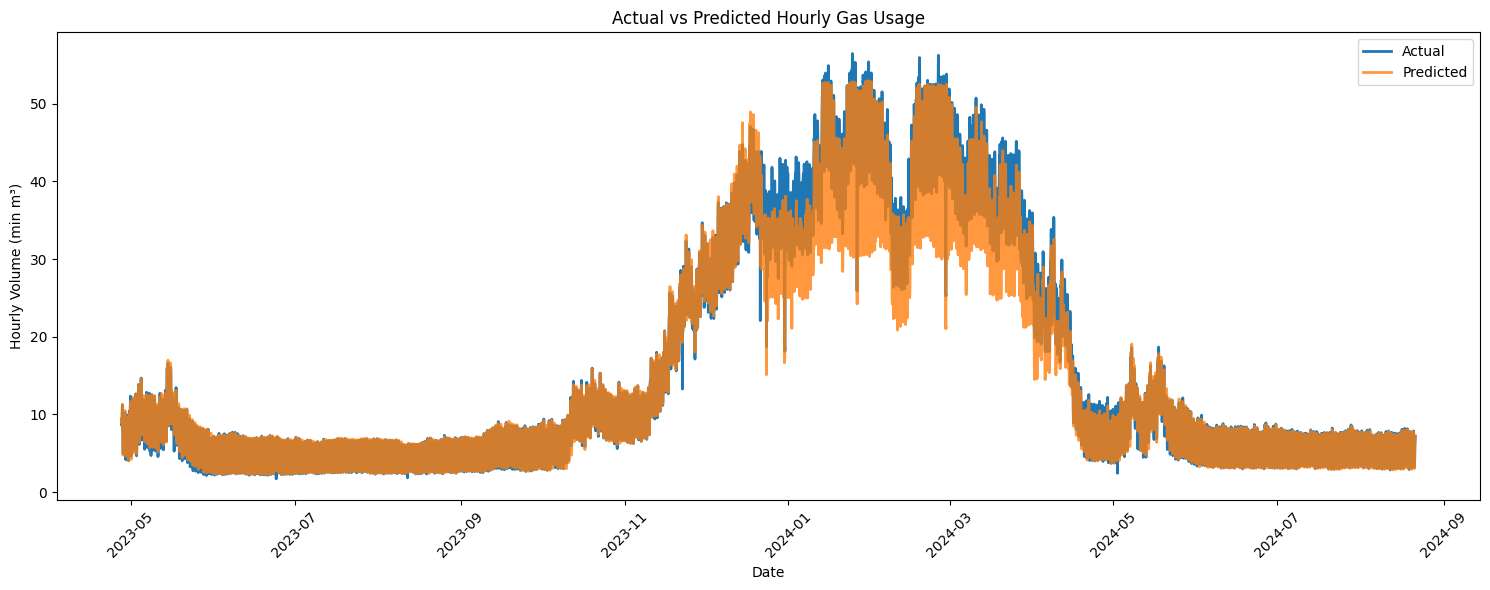

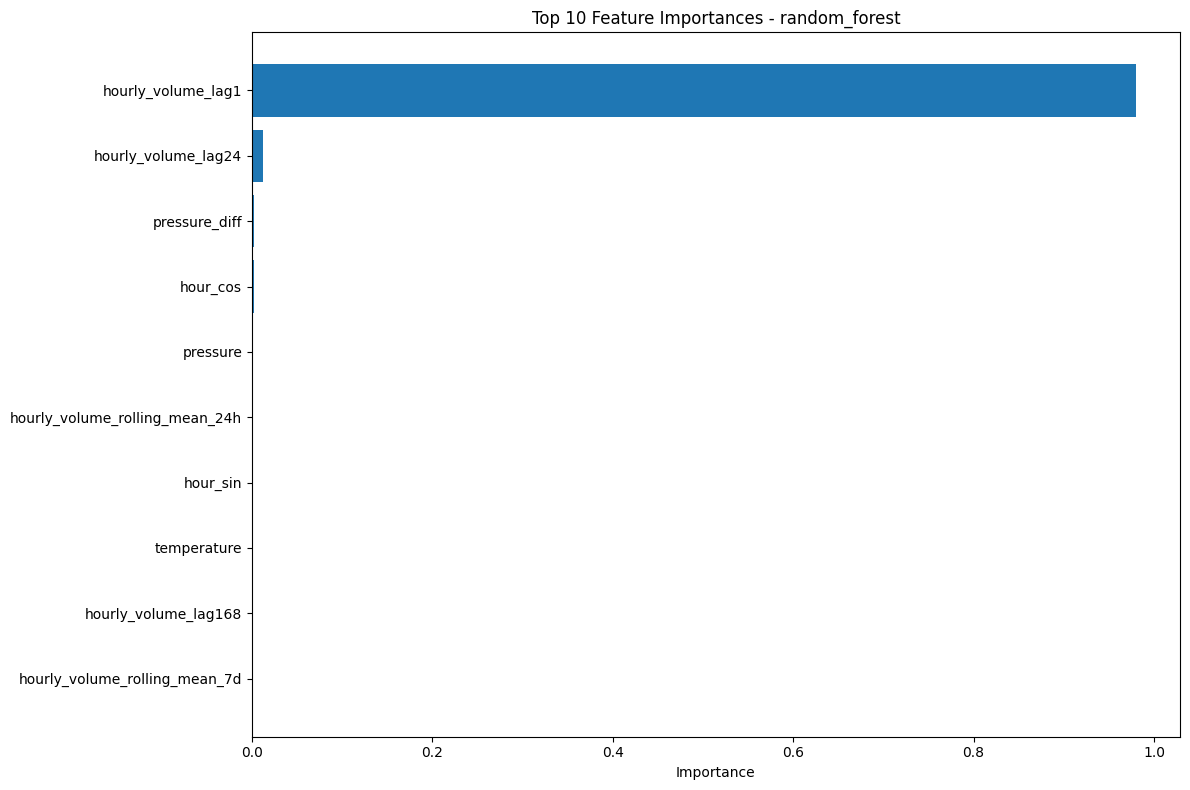


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9799
2. hourly_volume_lag24: 0.0122
3. pressure_diff: 0.0024
4. hour_cos: 0.0019
5. pressure: 0.0009
✅ Model saved to models/gas_usage_model.pkl
✅ Model training completed and saved!


In [33]:
from gas_prediction_fixed import train_model_colab, evaluate_all_models_colab, predict_future_colab
model = train_model_colab(data_path='data.csv', model_type='random_forest')

🔍 Starting comprehensive model evaluation...

Evaluating linear model:
Using Linear Regression
Training the model...

Model Evaluation:
Model Type: linear
Root Mean Squared Error: 1.0448
Mean Absolute Error: 0.6745
R² Score: 0.9950


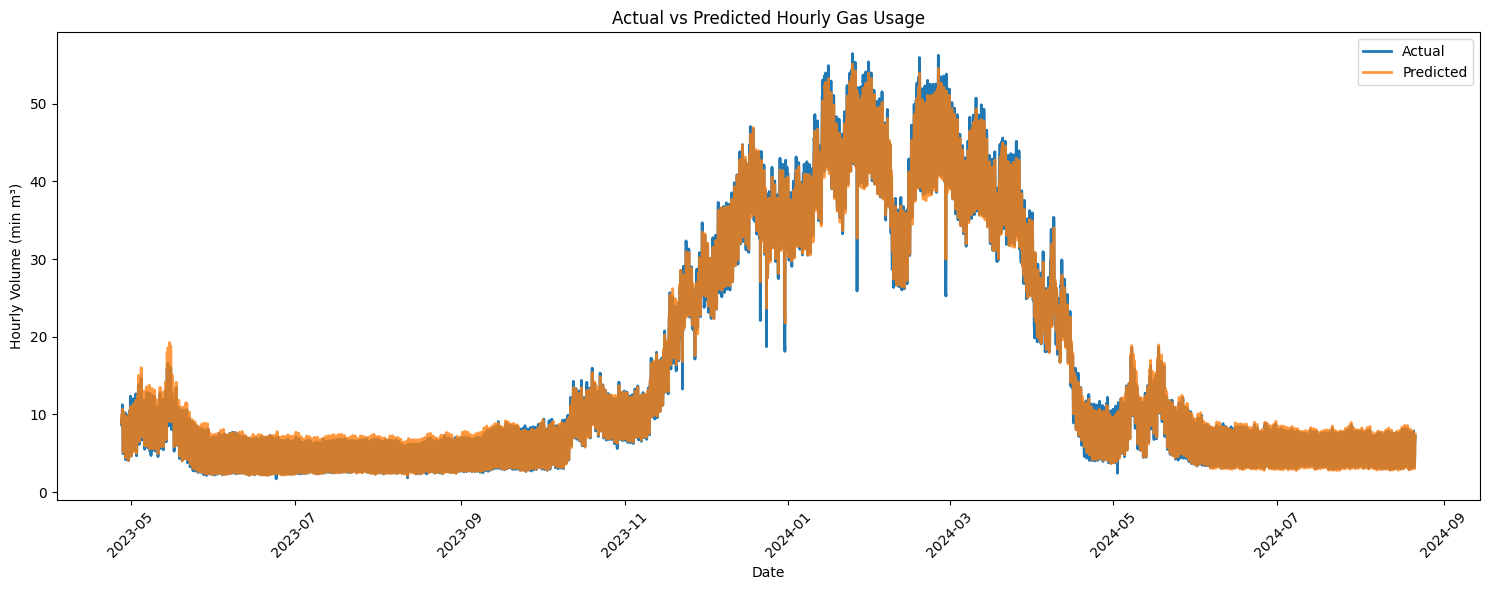


Evaluating random_forest model:
Using Random Forest Regressor
Training the model...

Model Evaluation:
Model Type: random_forest
Root Mean Squared Error: 2.5804
Mean Absolute Error: 1.2739
R² Score: 0.9693


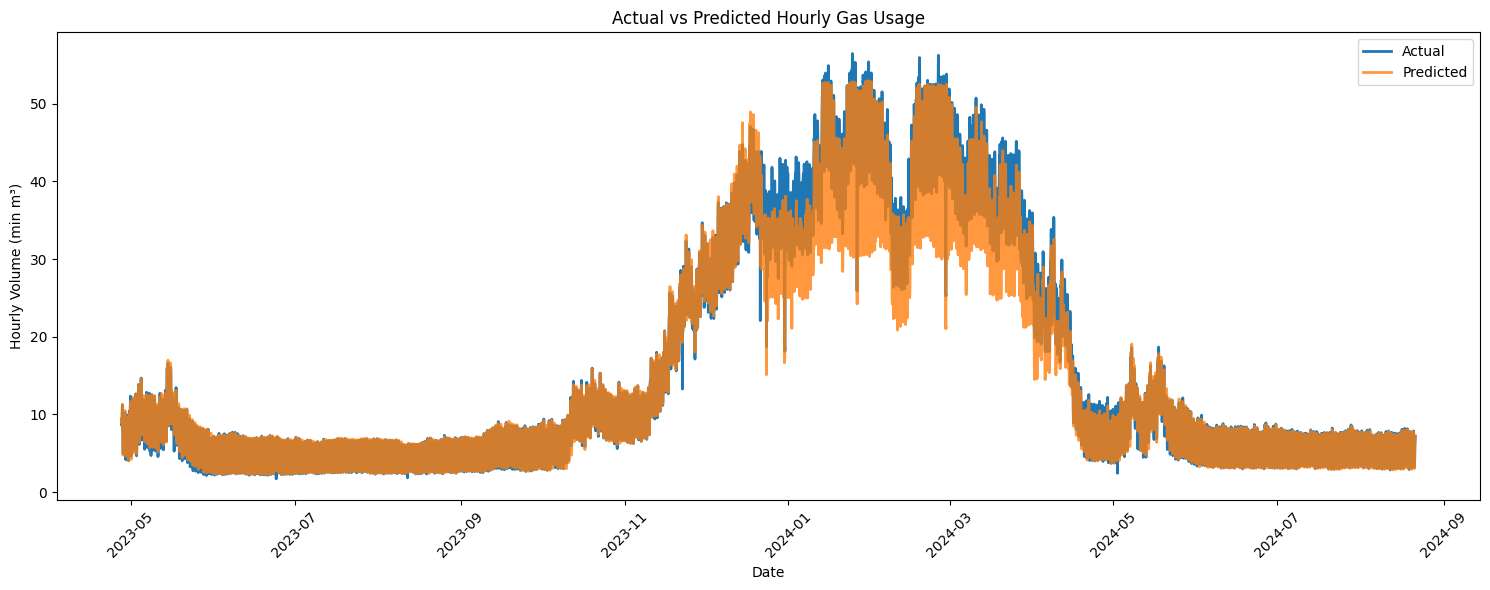

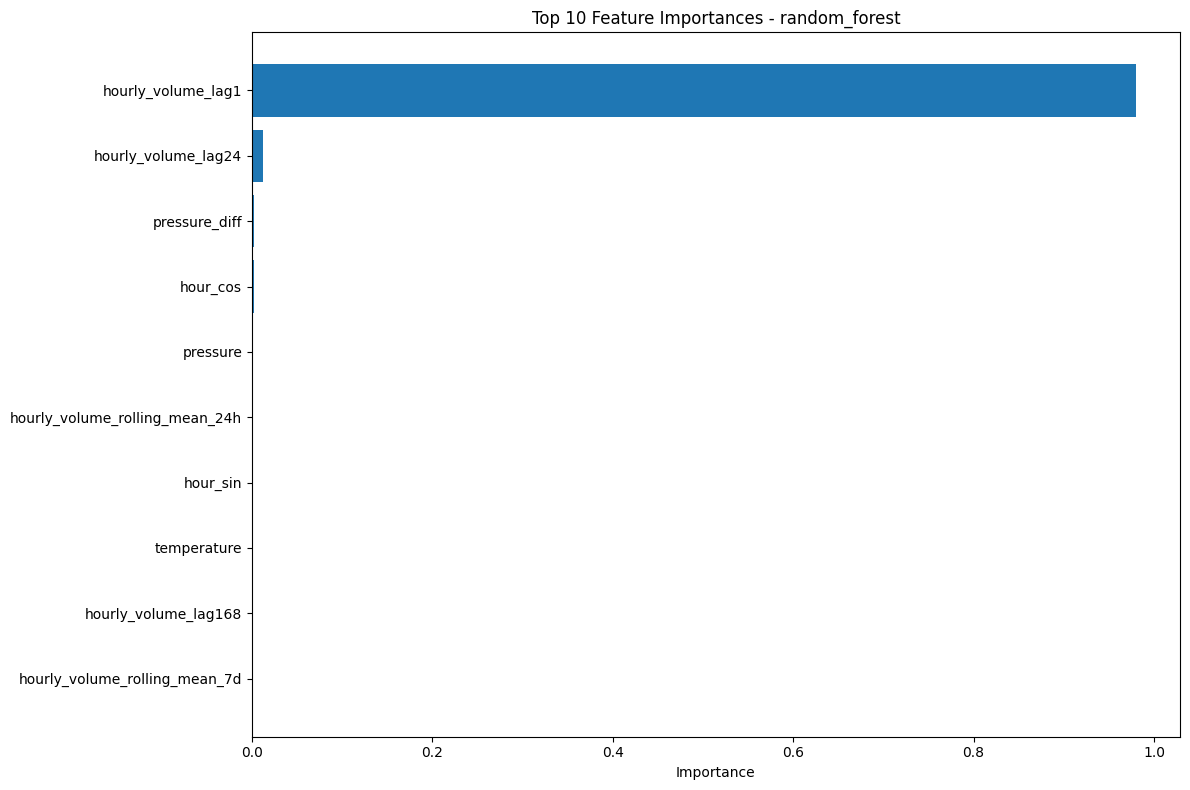


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9799
2. hourly_volume_lag24: 0.0122
3. pressure_diff: 0.0024
4. hour_cos: 0.0019
5. pressure: 0.0009

Evaluating gradient_boosting model:
Using Gradient Boosting Regressor
Training the model...

Model Evaluation:
Model Type: gradient_boosting
Root Mean Squared Error: 2.7950
Mean Absolute Error: 1.4571
R² Score: 0.9640


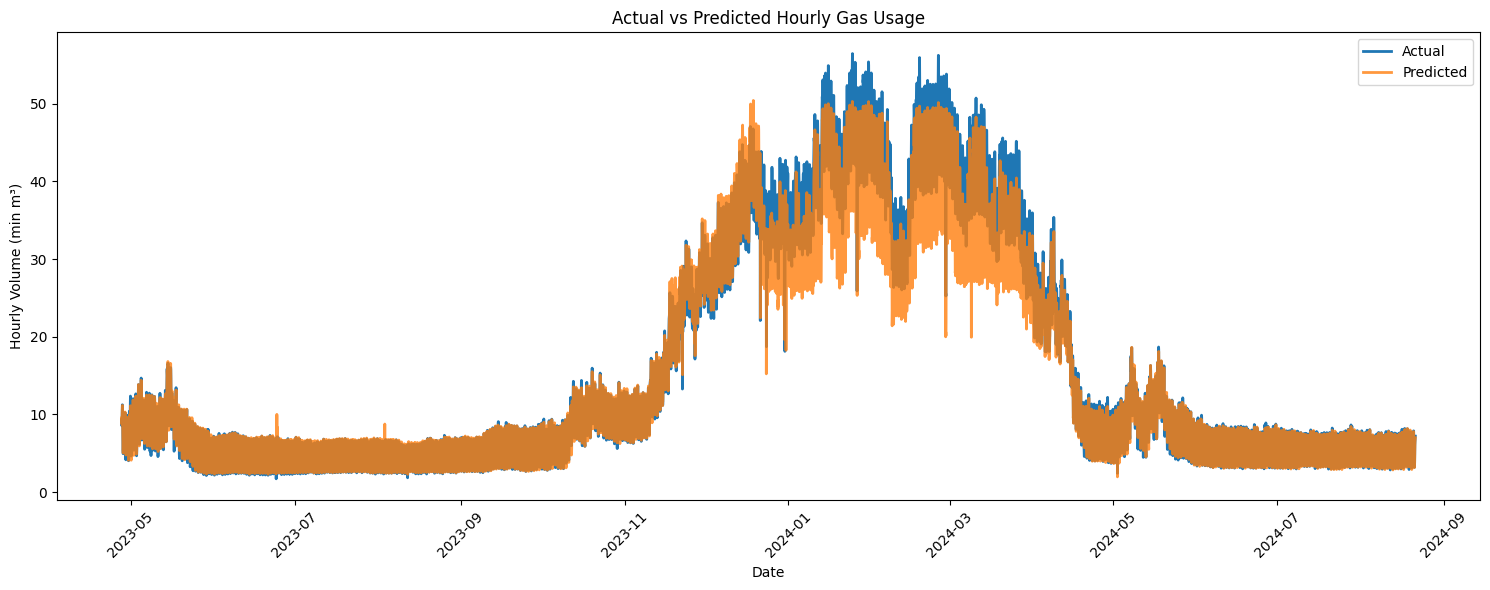

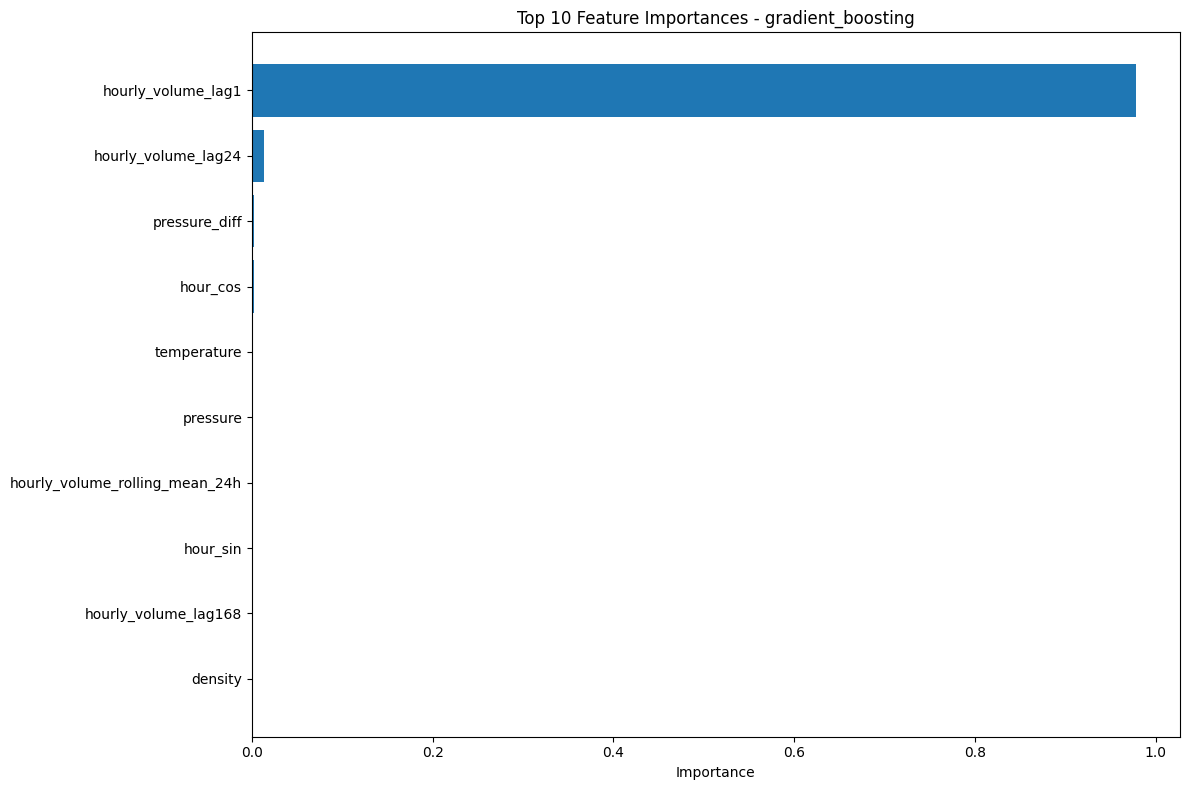


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9780
2. hourly_volume_lag24: 0.0134
3. pressure_diff: 0.0027
4. hour_cos: 0.0019
5. temperature: 0.0011

Evaluating xgboost model:
Using XGBoost Regressor
Training the model...

Model Evaluation:
Model Type: xgboost
Root Mean Squared Error: 3.0711
Mean Absolute Error: 1.5633
R² Score: 0.9565


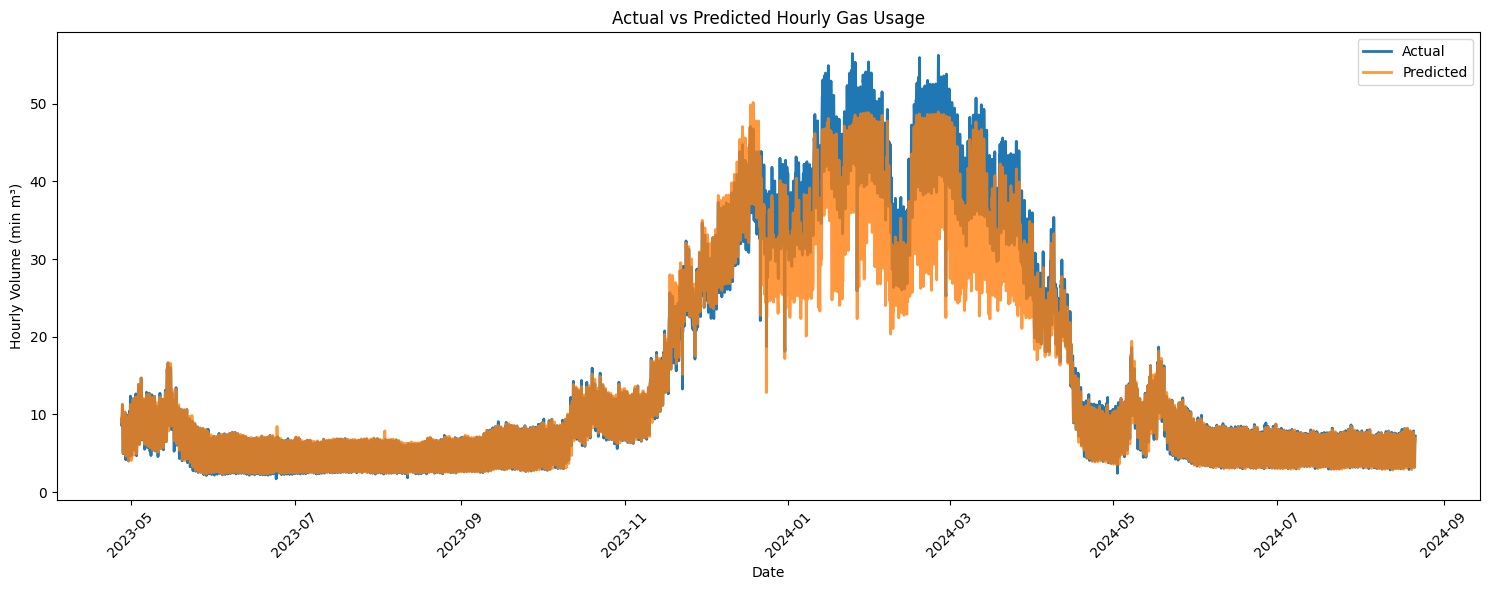

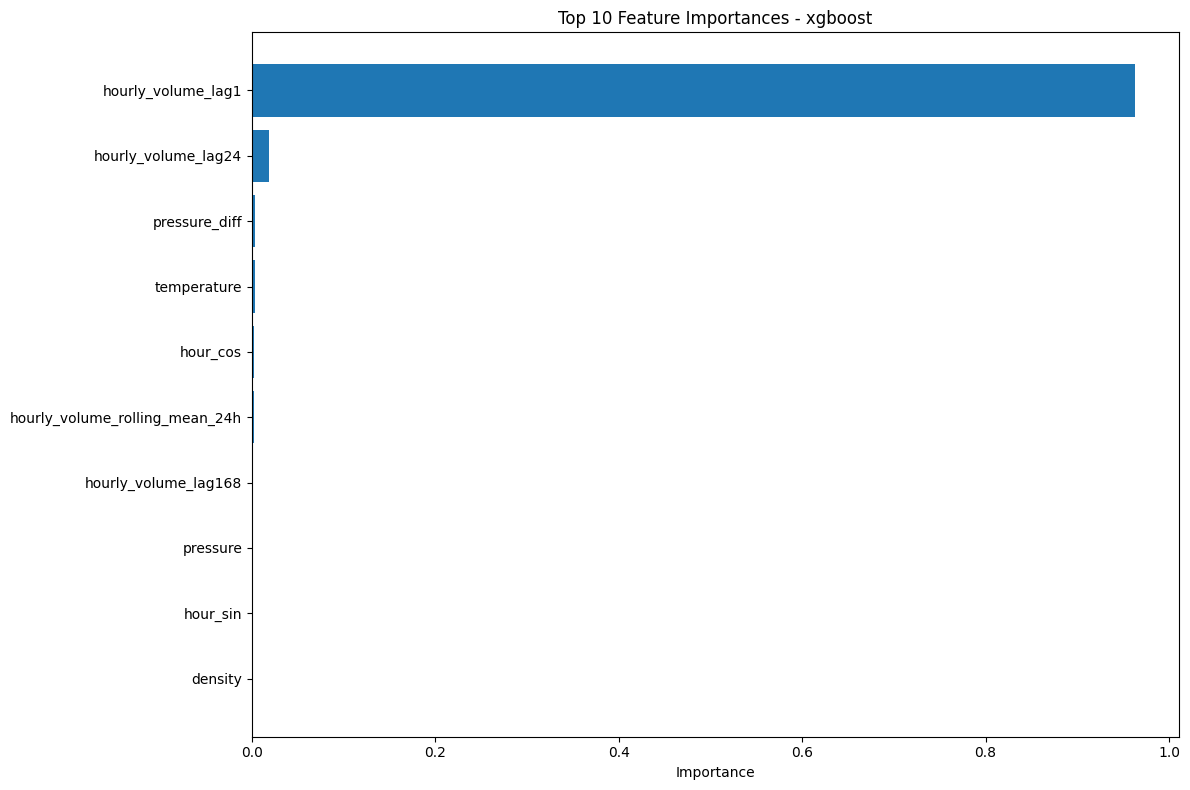


Top 5 Most Important Features:
1. hourly_volume_lag1: 0.9631
2. hourly_volume_lag24: 0.0184
3. pressure_diff: 0.0034
4. temperature: 0.0031
5. hour_cos: 0.0028

MODEL COMPARISON RESULTS:
                     rmse     mae      r2
linear             1.0448  0.6745  0.9950
random_forest      2.5804  1.2739  0.9693
gradient_boosting  2.7950  1.4571  0.9640
xgboost            3.0711  1.5633  0.9565

🏆 BEST MODEL: linear
   RMSE: 1.0448
   MAE: 0.6745
   R²: 0.9950

Retraining the best model (linear) and saving...
Using Linear Regression
Training the model...

Model Evaluation:
Model Type: linear
Root Mean Squared Error: 1.0448
Mean Absolute Error: 0.6745
R² Score: 0.9950


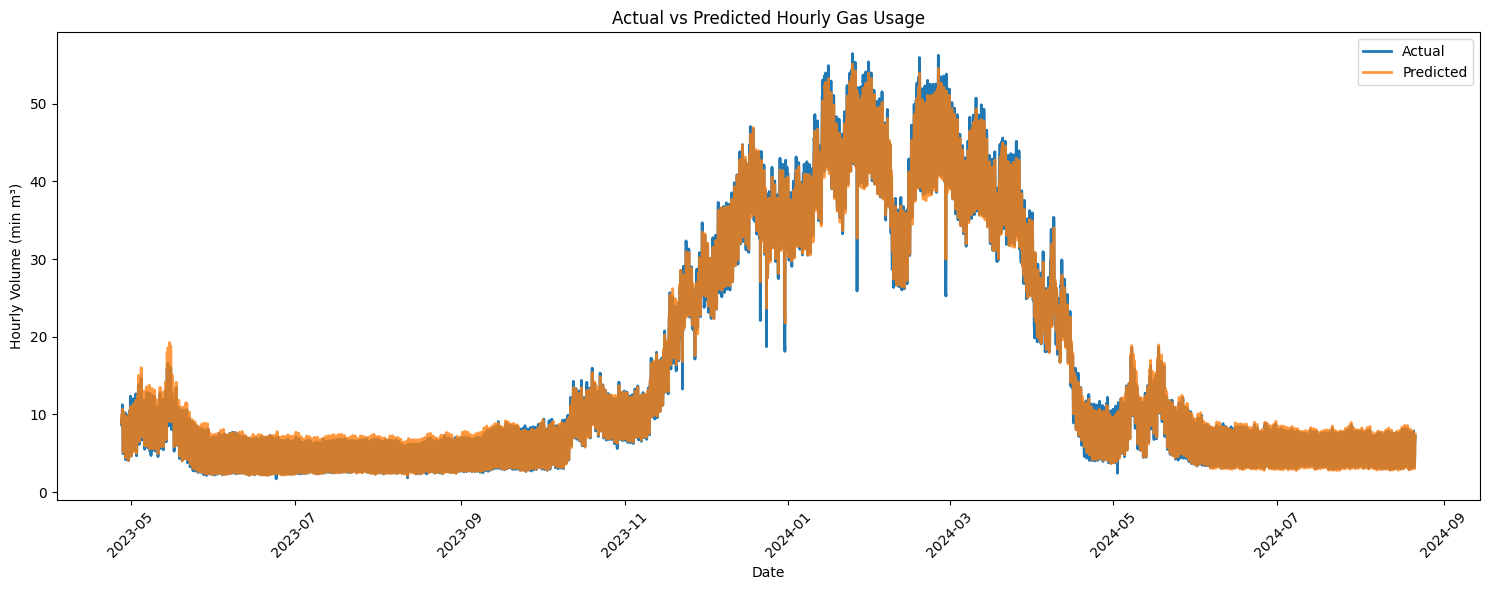

✅ Model saved to models/gas_usage_model.pkl
✅ Model evaluation completed!


In [34]:
from gas_prediction_fixed import evaluate_all_models_colab
model, results = evaluate_all_models_colab(data_path='data.csv')

In [35]:
import pandas as pd
import numpy as np
import joblib
import os

def quick_predict(date_str, data_path='data/data.csv', model_path='models/gas_usage_model.pkl'):
    """Quick prediction function that works standalone."""

    print(f"🎯 Making prediction for: {date_str}")

    # Load the CSV data
    df = pd.read_csv('data.csv')

    # Convert timestamp to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')

    # Create time-based features
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['day_of_month'] = df['timestamp'].dt.day
    df['month'] = df['timestamp'].dt.month
    df['year'] = df['timestamp'].dt.year

    # Convert hour to cyclical features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

    # Sort by timestamp
    df = df.sort_values('timestamp')

    # Calculate lag features
    df['hourly_volume_lag1'] = df['hourly_volume'].shift(1)
    df['hourly_volume_lag24'] = df['hourly_volume'].shift(24)
    df['hourly_volume_lag168'] = df['hourly_volume'].shift(168)

    # Calculate rolling averages
    df['hourly_volume_rolling_mean_24h'] = df['hourly_volume'].rolling(window=24).mean()
    df['hourly_volume_rolling_mean_7d'] = df['hourly_volume'].rolling(window=168).mean()

    # Drop rows with NaN values
    df = df.dropna()

    # Load the trained model
    print("✅ Loading trained model...")
    model_data = joblib.load(model_path)
    model = model_data['model']
    scaler = model_data['scaler']
    features = model_data['features']

    # Parse the input date
    try:
        future_date = pd.to_datetime(date_str, format='%d,%m,%Y %H:%M')
    except:
        try:
            future_date = pd.to_datetime(date_str, format='%d-%m-%Y %H:%M')
        except:
            raise ValueError("Invalid date format. Please use 'DD,MM,YYYY HH:MM' or 'DD-MM-YYYY HH:MM'")

    # Check if prediction is far in the future
    if df['timestamp'].max() < future_date - pd.Timedelta(days=7):
        print("⚠️  Warning: Future date is more than 7 days from the most recent data.")
        print("   Prediction accuracy may be reduced.")

    # Create future record
    future_record = pd.DataFrame({
        'hour': [future_date.hour],
        'day_of_week': [future_date.dayofweek],
        'day_of_month': [future_date.day],
        'month': [future_date.month],
        'year': [future_date.year]
    })

    # Add cyclical features
    future_record['hour_sin'] = np.sin(2 * np.pi * future_record['hour']/24)
    future_record['hour_cos'] = np.cos(2 * np.pi * future_record['hour']/24)
    future_record['day_of_week_sin'] = np.sin(2 * np.pi * future_record['day_of_week']/7)
    future_record['day_of_week_cos'] = np.cos(2 * np.pi * future_record['day_of_week']/7)

    # Find similar hour data for filling other features
    similar_hour_data = df[df['hour'] == future_date.hour]
    if len(similar_hour_data) > 0:
        # Use recent similar hour data
        avg_values = similar_hour_data.iloc[-7:].mean()
        most_recent = similar_hour_data.iloc[-1]

        # Fill in remaining features
        for feature in features:
            if feature not in future_record.columns:
                if feature in df.columns:
                    if 'lag' in feature or 'rolling' in feature:
                        future_record[feature] = avg_values[feature]
                    else:
                        future_record[feature] = most_recent[feature]
    else:
        raise ValueError("Not enough historical data to make a prediction for this hour.")

    # Scale and predict
    X_future = future_record[features]
    X_future_scaled = scaler.transform(X_future)
    prediction = model.predict(X_future_scaled)[0]

    result = {
        'date': future_date.strftime('%d-%m-%Y %H:%M'),
        'predicted_hourly_volume': round(prediction, 2),
        'units': 'min m³'
    }

    print(f"\n🔮 PREDICTION RESULT:")
    print(f"   Date: {result['date']}")
    print(f"   Predicted Hourly Gas Volume: {result['predicted_hourly_volume']} {result['units']}")

    return result

# Now use it:
prediction = quick_predict('22,10,2026 14:00')

🎯 Making prediction for: 22,10,2026 14:00
✅ Loading trained model...
⚠️  Warning: Future date is more than 7 days from the most recent data.
   Prediction accuracy may be reduced.

🔮 PREDICTION RESULT:
   Date: 22-10-2026 14:00
   Predicted Hourly Gas Volume: 8.18 min m³
